# Partie 1 — Chargement & analyse exploratoire (EDA)

**Projet CarPredictor** — estimation du prix de revente d'un véhicule d'occasion.

Objectifs de ce notebook :

1. Charger le jeu de données brut et vérifier sa structure (types, dimensions).
2. Produire les statistiques descriptives (moyennes, médianes, écarts-types, fréquences).
3. Visualiser les distributions (kilométrage, prix, année).
4. Étudier les corrélations et l'impact de `year` et `km_driven` sur `selling_price`
   (matrice de corrélation, heatmap, pairplot, nuages de points).
5. **Justifier** quelles colonnes sont réellement pertinentes pour la prédiction.

> Le nettoyage (valeurs manquantes, doublons, aberrantes), l'encodage, la séparation
> train/test et la normalisation sont traités dans le notebook suivant
> `01b_nettoyage_preparation.ipynb`. Ici, on **observe sans modifier** : toute l'analyse
> est faite sur les données brutes afin de diagnostiquer les problèmes à corriger.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


RAW_PATH = "../data/raw/car-price-raw-data.csv"
FIG_DIR = "../reports/figures"


pandas 3.0.5 | numpy 2.5.3 | seaborn 0.13.2


---
## 1. Chargement des données et structure

In [2]:
df = pd.read_csv(RAW_PATH)
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,"2,007.00",60000,"70,000.00",Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,"2,007.00",135000,"50,000.00",Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,"2,012.00",600000,"100,000.00",Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,"2,017.00",250000,"46,000.00",Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,"2,014.00",450000,"141,000.00",Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,"2,007.00",140000,"125,000.00",Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,"2,016.00",550000,"25,000.00",Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,"2,014.00",240000,"60,000.00",Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,"2,015.00",850000,"25,000.00",Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,"2,017.00",365000,"78,000.00",CNG,Individual,Manual,First Owner


In [3]:
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes\n")
print("Types des colonnes :")
print(df.dtypes)

Dimensions : 4340 lignes x 8 colonnes

Types des colonnes :
name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   str    
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4275 non-null   str    
 6   transmission   4340 non-null   str    
 7   owner          4254 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 514.7 KB


In [5]:
# Vue synthétique : type, nb de valeurs manquantes, nb de modalités distinctes, exemple
structure = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "manquants": df.isna().sum(),
    "% manquants": (df.isna().mean() * 100).round(2),
    "valeurs_uniques": df.nunique(),
    "exemple": [df[col].dropna().iloc[0] for col in df.columns],
})
structure

,type,non_null,manquants,% manquants,valeurs_uniques,exemple
name,str,4340,0,0.00,1491,Maruti 800 AC
year,float64,4297,43,0.99,27,"2,007.00"
selling_price,int64,4340,0,0.00,445,60000
km_driven,float64,4167,173,3.99,750,"70,000.00"
fuel,str,4254,86,1.98,5,Petrol
seller_type,str,4275,65,1.50,3,Individual
transmission,str,4340,0,0.00,2,Manual
owner,str,4254,86,1.98,5,First Owner


### Lecture de la structure

Le fichier contient **4 340 lignes** et **8 colonnes**.

| Colonne | Type lu | Rôle attendu |
|---|---|---|
| `name` | texte | identifiant commercial du modèle (très haute cardinalité) |
| `year` | `float64` | année de mise en circulation — **numérique** |
| `selling_price` | `int64` | **variable cible** (prix de vente) |
| `km_driven` | `float64` | kilométrage — **numérique** |
| `fuel` | texte | carburant — **catégoriel** |
| `seller_type` | texte | type de vendeur — **catégoriel** |
| `transmission` | texte | boîte de vitesses — **catégoriel binaire** |
| `owner` | texte | nombre de propriétaires précédents — **catégoriel ordinal** |

Deux remarques sur les types :

- `year` et `km_driven` sont lus en `float64` **uniquement à cause des valeurs manquantes**
  (une colonne entière contenant des `NaN` est promue en flottant). Ce sont bien des entiers
  logiques : on pourra les recaster en `Int64` après imputation.
- `owner` est stocké en texte (`First Owner`, `Second Owner`, …) alors qu'il porte un **ordre**.
  Cet ordre devra être conservé lors de l'encodage (encodage ordinal, et non one-hot).

---
## 2. Statistiques descriptives

### 2.1 Variables numériques

In [6]:
num_cols = ["year", "km_driven", "selling_price"]
cat_cols = ["fuel", "seller_type", "transmission", "owner"]

desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["skew"] = df[num_cols].skew()          # asymétrie
desc["kurtosis"] = df[num_cols].kurtosis()  # aplatissement
desc["IQR"] = desc["75%"] - desc["25%"]
desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "IQR", "skew", "kurtosis"]]

,count,mean,median,std,min,25%,50%,75%,max,IQR,skew,kurtosis
year,"4,297.00","2,013.09","2,014.00",4.22,"1,992.00","2,011.00","2,014.00","2,016.00","2,020.00",5.00,-0.84,0.68
km_driven,"4,167.00","66,237.20","60,000.00","46,635.46",1.00,"35,000.00","60,000.00","90,000.00","806,599.00","55,000.00",2.71,24.12
selling_price,"4,340.00","504,127.31","350,000.00","578,548.74","20,000.00","208,749.75","350,000.00","600,000.00","8,900,000.00","391,250.25",4.89,37.09


In [7]:
# Quantiles fins : utiles pour situer les queues de distribution
df[num_cols].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995]).T

,0.01,0.05,0.25,0.50,0.75,0.95,0.99,0.99
year,"2,001.00","2,005.00","2,011.00","2,014.00","2,016.00","2,019.00","2,020.00","2,020.00"
km_driven,"1,426.40","10,000.00","35,000.00","60,000.00","90,000.00","140,000.00","218,680.00","250,000.00"
selling_price,"55,000.00","80,000.00","208,749.75","350,000.00","600,000.00","1,300,000.00","3,200,000.00","4,261,000.00"


**Lecture des statistiques numériques**

- `selling_price` : moyenne ≈ **504 127** contre une médiane de **350 000**. La moyenne est
  ~1,4× la médiane et l'asymétrie (*skew*) vaut **+4,9** → distribution très étalée à droite,
  tirée par quelques véhicules de luxe (max = 8 900 000). **La médiane est ici un bien
  meilleur résumé que la moyenne**, ce qui justifiera l'imputation par la médiane.
- `km_driven` : médiane **60 000 km**, moyenne **66 237 km**, max **806 599 km**.
  Asymétrie **+2,7** → là aussi une longue queue à droite, avec des valeurs physiquement
  douteuses à inspecter.
- `year` : médiane **2014**, min **1992**, max **2020**. Asymétrie **-0,84** (queue à gauche) :
  le parc est majoritairement récent, avec quelques véhicules anciens.

L'écart systématique entre moyenne et médiane sur les deux variables monétaire/kilométrique
est le premier signal de la présence de valeurs extrêmes.

### 2.2 Variables catégorielles — fréquences

In [8]:
for col in cat_cols:
    freq = df[col].value_counts(dropna=False).to_frame("effectif")
    freq["%"] = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    print(f"--- {col} ({df[col].nunique()} modalités) ---")
    print(freq, "\n")

--- fuel (5 modalités) ---
          effectif     %
fuel                    
Diesel        2116 48.76
Petrol        2077 47.86
NaN             86  1.98
CNG             38  0.88
LPG             22  0.51
Electric         1  0.02 

--- seller_type (3 modalités) ---
                  effectif     %
seller_type                     
Individual            3198 73.69
Dealer                 976 22.49
Trustmark Dealer       101  2.33
NaN                     65  1.50 

--- transmission (2 modalités) ---
              effectif     %
transmission                
Manual            3892 89.68
Automatic          448 10.32 

--- owner (5 modalités) ---
                      effectif     %
owner                               
First Owner               2771 63.85
Second Owner              1084 24.98
Third Owner                302  6.96
NaN                         86  1.98
Fourth & Above Owner        80  1.84
Test Drive Car              17  0.39 



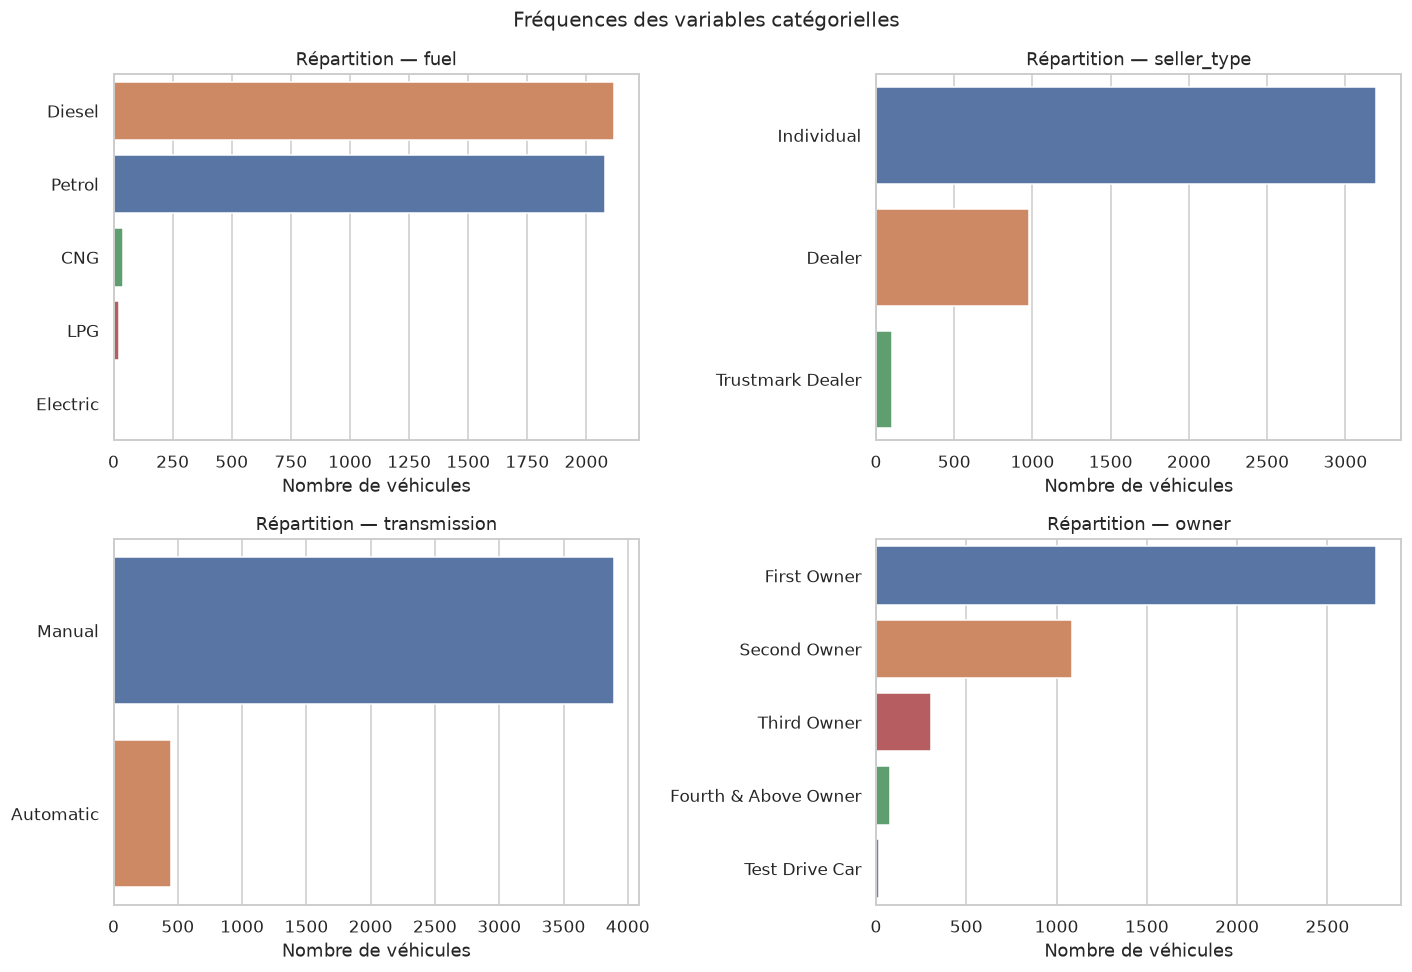

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(f"Répartition — {col}")
    ax.set_xlabel("Nombre de véhicules")
    ax.set_ylabel("")
fig.suptitle("Fréquences des variables catégorielles", fontsize=13)
fig.tight_layout()
plt.show()

**Lecture des fréquences**

- `fuel` : **Diesel (2 116)** et **Petrol (2 077)** représentent ~97 % des observations.
  `CNG` (38), `LPG` (22) et surtout **`Electric` (1 seule ligne)** sont ultra-minoritaires :
  une modalité à un seul individu n'est pas apprenable et risque de se retrouver
  exclusivement dans le train ou le test après découpage.
- `seller_type` : **Individual (3 198)**, `Dealer` (976), `Trustmark Dealer` (101) — déséquilibré
  mais les trois modalités restent exploitables.
- `transmission` : **Manual (3 892)** vs `Automatic` (448) — variable binaire, ~10 % d'automatiques.
- `owner` : `First Owner` (2 771) → `Fourth & Above Owner` (80), plus une modalité
  **`Test Drive Car` (17)** qui n'est pas un rang de propriétaire mais un statut particulier
  (véhicule de démonstration, quasi neuf).

`name` compte **1 491 modalités distinctes** pour 4 340 lignes (~1 ligne sur 3 est un modèle unique) :
inexploitable telle quelle (voir §5).

---
## 3. Distributions : kilométrage, prix, année

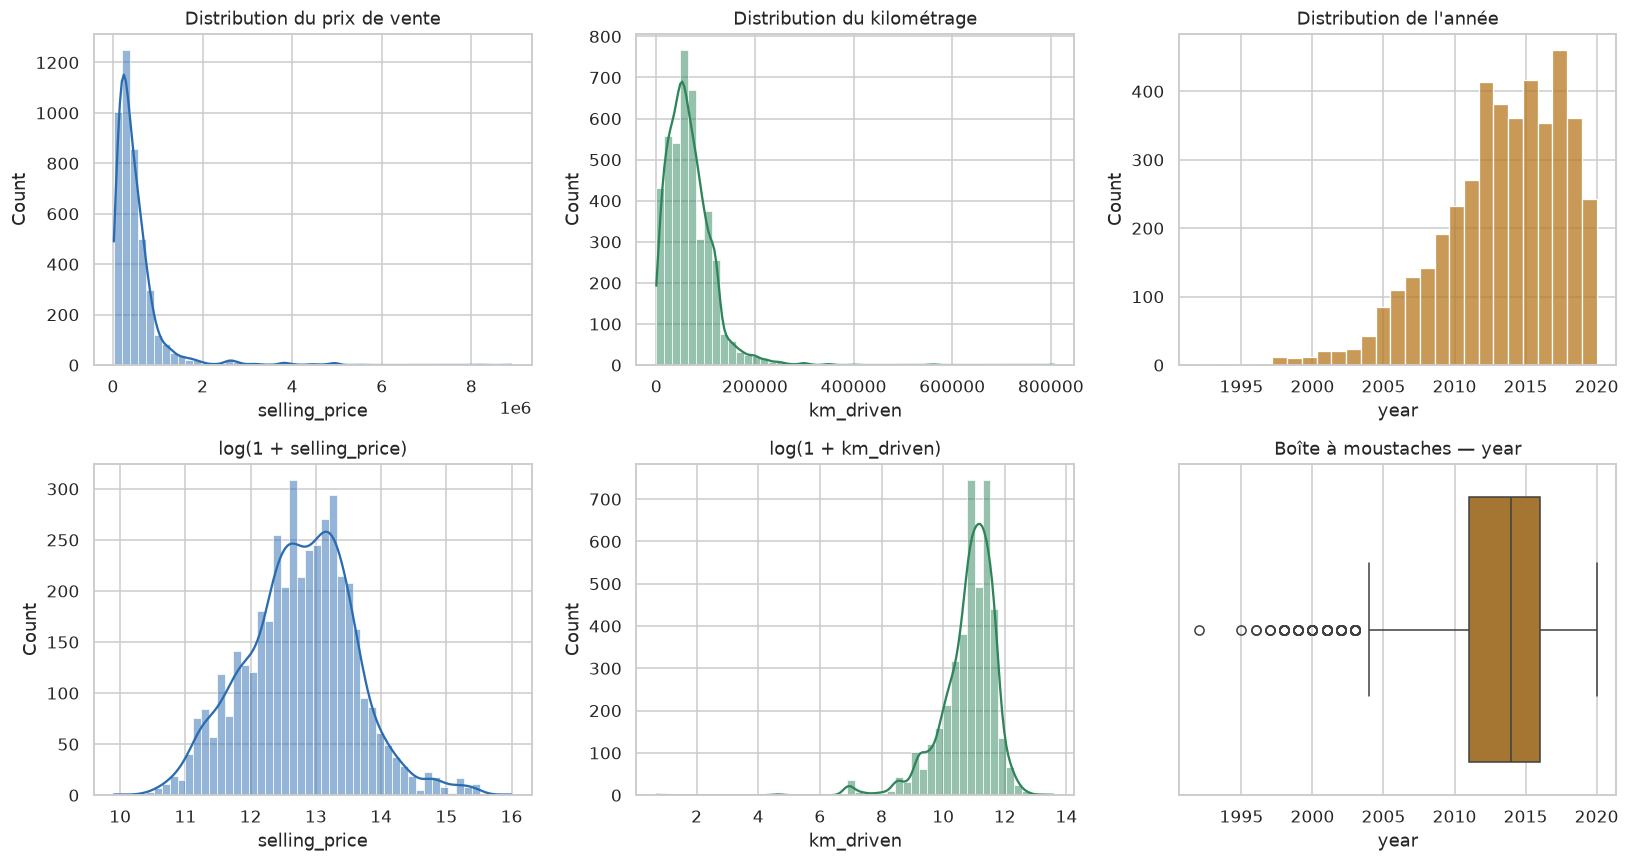

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0, 0], color="#2b6cb0")
axes[0, 0].set_title("Distribution du prix de vente")
axes[0, 0].set_xlabel("selling_price")

sns.histplot(df["km_driven"], bins=50, kde=True, ax=axes[0, 1], color="#2f855a")
axes[0, 1].set_title("Distribution du kilométrage")
axes[0, 1].set_xlabel("km_driven")

sns.histplot(df["year"].dropna(), bins=int(df["year"].nunique()), ax=axes[0, 2], color="#b7791f")
axes[0, 2].set_title("Distribution de l'année")
axes[0, 2].set_xlabel("year")

# Même distributions en échelle log : rend la forme lisible malgré la queue droite
sns.histplot(np.log1p(df["selling_price"]), bins=50, kde=True, ax=axes[1, 0], color="#2b6cb0")
axes[1, 0].set_title("log(1 + selling_price)")

sns.histplot(np.log1p(df["km_driven"].dropna()), bins=50, kde=True, ax=axes[1, 1], color="#2f855a")
axes[1, 1].set_title("log(1 + km_driven)")

sns.boxplot(x=df["year"], ax=axes[1, 2], color="#b7791f")
axes[1, 2].set_title("Boîte à moustaches — year")

fig.tight_layout()
plt.show()

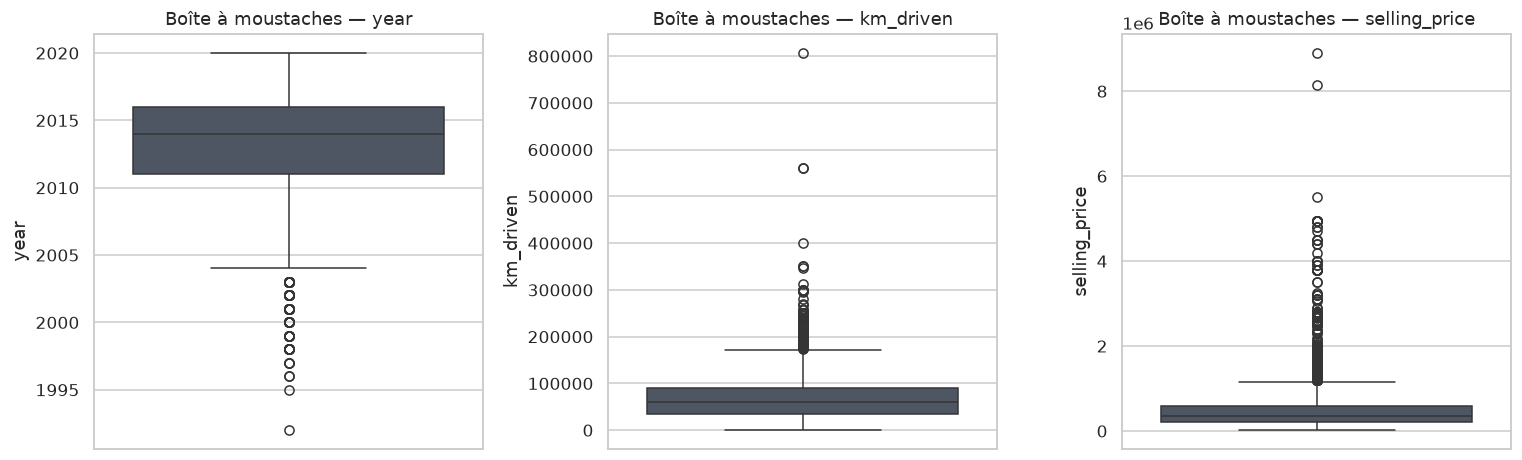

In [11]:
# Boîtes à moustaches des 3 variables numériques : première détection visuelle des aberrantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4a5568")
    ax.set_title(f"Boîte à moustaches — {col}")
fig.tight_layout()
plt.show()

**Lecture des distributions**

- **Prix** : distribution unimodale fortement asymétrique à droite. En échelle logarithmique,
  elle devient quasi normale → indice fort qu'une transformation `log` de la cible (ou des
  modèles robustes type arbres/ensembles) sera préférable à une régression linéaire brute.
- **Kilométrage** : même profil, avec une poignée de points au-delà de **300 000 km**
  (dont un **806 599 km**) très détachés du reste du nuage.
- **Année** : concentration sur **2010-2019**, queue gauche jusqu'à 1992. Les boîtes à
  moustaches signalent les années anciennes comme « atypiques » au sens statistique,
  mais elles restent parfaitement **plausibles** (un véhicule de 1995 existe).

C'est cette distinction — *atypique statistiquement* ≠ *incohérent* — qui guidera le
traitement des valeurs aberrantes dans le notebook suivant.

---
## 4. Corrélations et impact de l'année et du kilométrage sur le prix

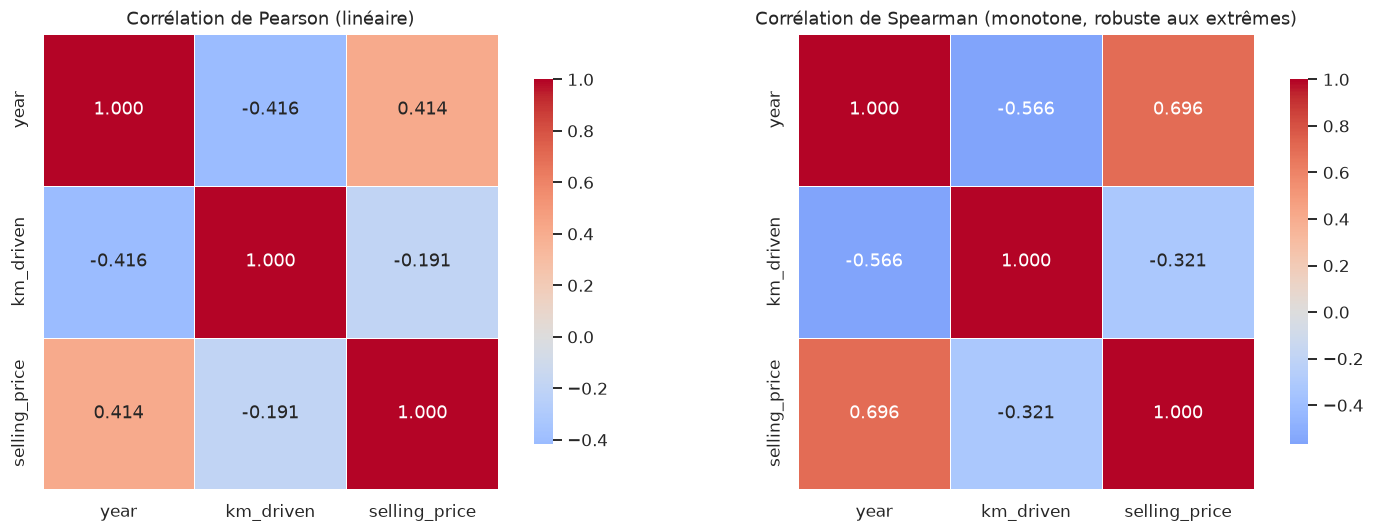

,year,km_driven,selling_price
year,1.00,-0.42,0.41
km_driven,-0.42,1.00,-0.19
selling_price,0.41,-0.19,1.00


In [12]:
corr = df[num_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title("Corrélation de Pearson (linéaire)")

corr_s = df[num_cols].corr(method="spearman")
sns.heatmap(corr_s, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=axes[1])
axes[1].set_title("Corrélation de Spearman (monotone, robuste aux extrêmes)")

fig.tight_layout()
plt.show()

corr

---
## 6. Justification des colonnes retenues pour la prédiction

| Colonne | Décision | Justification |
|---|---|---|
| `selling_price` | **Cible** | Variable à prédire. Fortement asymétrique (*skew* +4,9) → transformation `log` à envisager côté modélisation. |
| `year` | **Conservée** | Prédicteur numérique le plus corrélé au prix (**+0,41**) ; la décote annuelle est la mécanique économique centrale du marché de l'occasion. |
| `km_driven` | **Conservée** | Corrélation linéaire modérée (**-0,19**) mais relation clairement décroissante et monotone sur les prix médians par tranche ; effet bien plus net sur `log(prix)`. Deuxième déterminant métier de la décote. |
| `fuel` | **Conservée** | Écart de prix médian marqué entre Diesel/Petrol et CNG/LPG. *Réserve* : la modalité `Electric` (1 ligne) sera regroupée avec les modalités rares. |
| `seller_type` | **Conservée** | Trois modalités bien séparées en prix médian ; proxy du segment et du canal de vente. |
| `transmission` | **Conservée** | Variable binaire la plus discriminante du jeu de données (automatique ≫ manuelle). |
| `owner` | **Conservée (ordinale)** | Décroissance monotone du prix avec le rang du propriétaire. À encoder en préservant l'ordre, pas en one-hot. |
| `name` | **Écartée** | **1 491 modalités** pour 4 340 lignes : un one-hot exploserait la dimension (plus de colonnes que de lignes) et produirait un sur-apprentissage massif ; beaucoup de modalités n'apparaîtraient que dans le train ou que dans le test. La marque extraite reste une **piste d'amélioration** documentée, hors périmètre du prétraitement demandé (`fuel`, `seller_type`, `transmission`). |

### Périmètre retenu

- **Cible** : `selling_price`
- **Features numériques** : `year`, `km_driven`
- **Features catégorielles** : `fuel`, `seller_type`, `transmission`, `owner`

### Problèmes à corriger, identifiés par cette EDA

1. **Valeurs manquantes** : `km_driven` (173), `fuel` (86), `owner` (86), `seller_type` (65),
   `year` (43). La cible `selling_price` n'en a aucune — c'est essentiel, une ligne sans cible
   ne serait pas imputable mais à supprimer.
2. **Doublons** : **635 lignes strictement identiques** (≈ 14,6 % du jeu).
3. **Valeurs extrêmes** : queue droite marquée sur `selling_price` et `km_driven`
   (jusqu'à 806 599 km), queue gauche sur `year`. À trier entre *légitimes* et *incohérentes*.
4. **Types** : `year` / `km_driven` à recaster en entiers après imputation.
5. **Modalités rares** : `Electric` (1 obs.), `Test Drive Car` (17 obs.).

➡️ Suite dans **`01b_nettoyage_preparation.ipynb`**.